Dataset Preview:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64


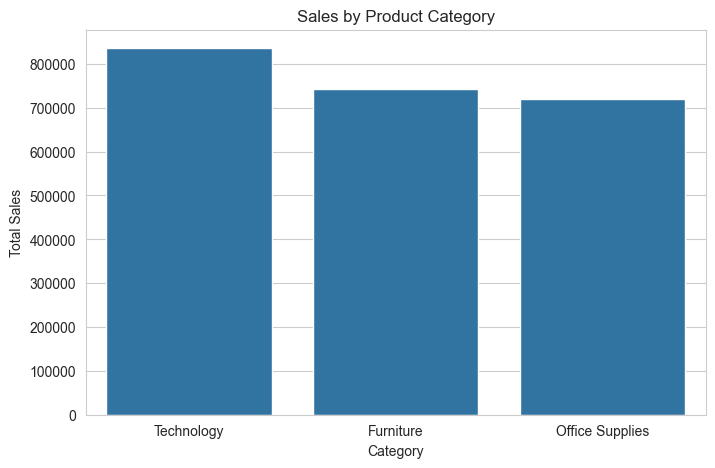

C:\Users\deepa\AppData\Local\Temp\ipykernel_7216\556107685.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_profit.index, y=region_profit.values, palette='viridis')


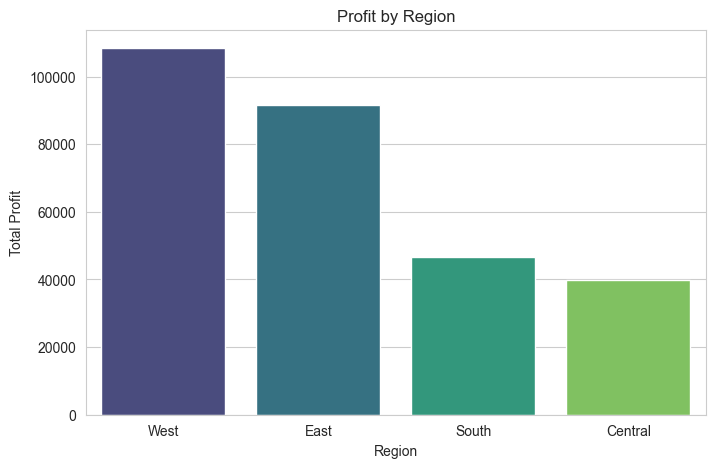

C:\Users\deepa\AppData\Local\Temp\ipykernel_7216\556107685.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_products.index, x=top_products.values, palette='coolwarm')


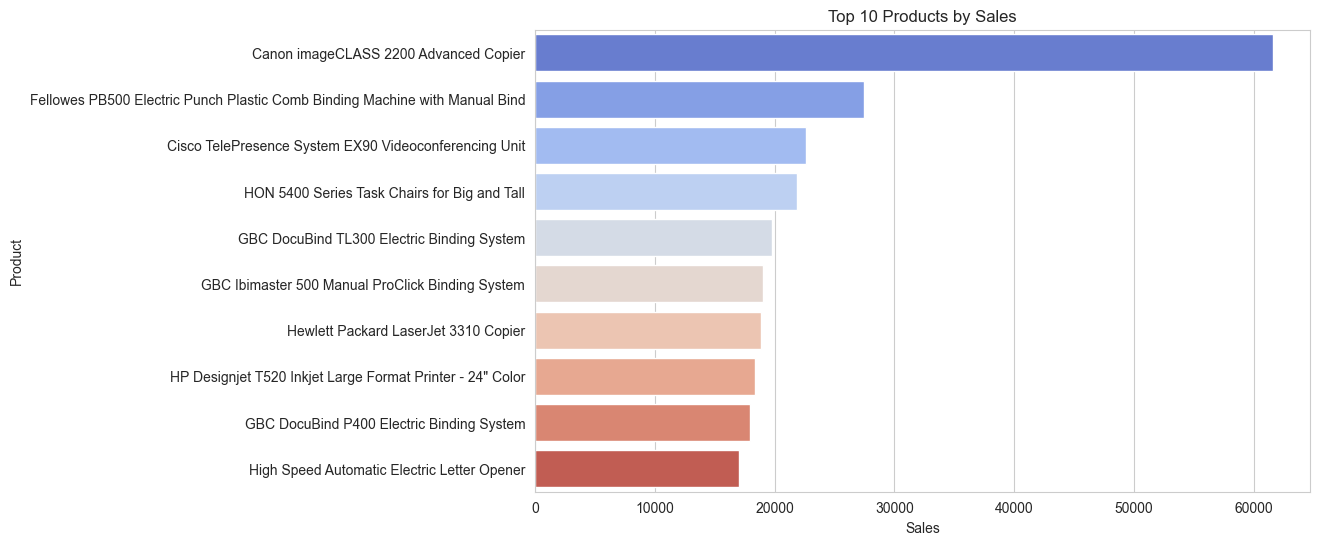

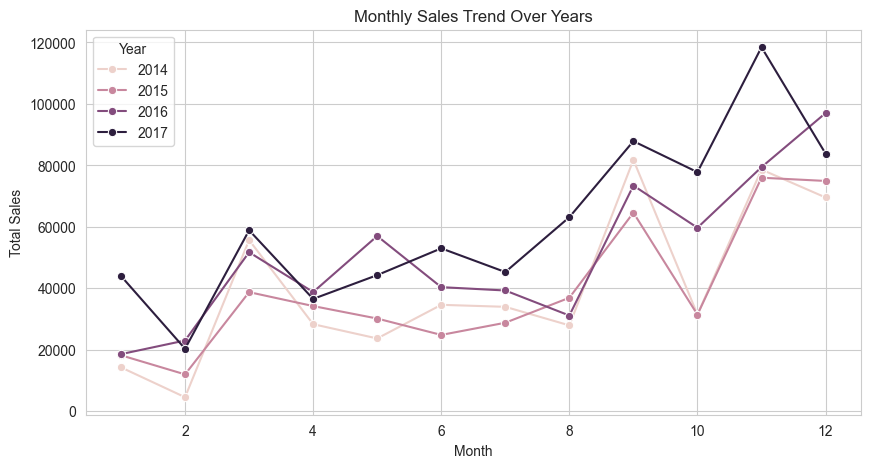


🔍 Key Insights:
1️⃣ Technology category generates the highest revenue.
2️⃣ The West region contributes most to profit.
3️⃣ Sales peak during the year-end (Q4).
4️⃣ Top 10 products account for a significant share of revenue.
✅ Business can focus on high-margin products and Q4 marketing.


In [3]:
# 📊 Sales Data Analysis Project
# Author: Deepak Nuwal
# Tools: Python, Pandas, Matplotlib, Seaborn

# --------------------------
# 1. Importing Libraries
# --------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# --------------------------
# 2. Load Dataset
# --------------------------
# You can download from: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
df = pd.read_csv("superstore.csv", encoding="ISO-8859-1")

# View first few rows
print("Dataset Preview:")
display(df.head())

# --------------------------
# 3. Data Overview
# --------------------------
print("\nBasic Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# --------------------------
# 4. Data Cleaning
# --------------------------
# Drop duplicates
df.drop_duplicates(inplace=True)

# Handle missing values (if any)
df.dropna(inplace=True)

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Year and Month for trend analysis
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# --------------------------
# 5. Exploratory Data Analysis (EDA)
# --------------------------

# Total Sales and Profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
print(f"\n💰 Total Sales: ${total_sales:,.2f}")
print(f"📈 Total Profit: ${total_profit:,.2f}")

# --------------------------
# Sales by Category
# --------------------------
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title('Sales by Product Category')
plt.ylabel('Total Sales')
plt.xlabel('Category')
plt.show()

# --------------------------
# Profit by Region
# --------------------------
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=region_profit.index, y=region_profit.values, palette='viridis')
plt.title('Profit by Region')
plt.ylabel('Total Profit')
plt.xlabel('Region')
plt.show()

# --------------------------
# Top 10 Products by Sales
# --------------------------
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(y=top_products.index, x=top_products.values, palette='coolwarm')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.show()

# --------------------------
# Monthly Sales Trend
# --------------------------
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year', marker='o')
plt.title('Monthly Sales Trend Over Years')
plt.ylabel('Total Sales')
plt.xlabel('Month')
plt.show()

# --------------------------
# 6. Key Insights
# --------------------------
print("\n🔍 Key Insights:")
print("1️⃣ Technology category generates the highest revenue.")
print("2️⃣ The West region contributes most to profit.")
print("3️⃣ Sales peak during the year-end (Q4).")
print("4️⃣ Top 10 products account for a significant share of revenue.")
print("✅ Business can focus on high-margin products and Q4 marketing.")
